In [4]:
# Requiero Mesa >= 3.5
# Importamos las clases que se requieren para manejar los agentes (Agent) y su entorno (Model).
# Cada modelo puede contener múltiples agentes.
from mesa import Agent, Model

# Debido a que necesitamos que existe un solo agente por celda, elegimos ''SingleGrid''.
from mesa.space import SingleGrid

# Haremos uso de ''DataCollector'' para obtener información de cada paso de la simulación.
from mesa.datacollection import DataCollector

# Haremos uso de ''batch_run'' para ejecutar varias simulaciones
from mesa.batchrunner import batch_run

# matplotlib lo usaremos crear una animación de cada uno de los pasos del modelo.
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

# Importamos los siguientes paquetes para el mejor manejo de valores numéricos.
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()

# Importamos esta librería para generar numeros aleatorios más adelante
import sys
import random
from matplotlib.colors import ListedColormap

import heapq


In [ ]:
def get_grid(model):
    grid = np.zeros( (model.grid.width, model.grid.height) )
    for content, (x, y) in model.grid.coord_iter():
        grid[x][y] = model.cells[x][y]
        if content != None:
            grid[x][y] = 7
    return grid

In [ ]:
class FlashPoint(Model):
    def __init__(self, width=10, height=8, agents=1, **kwargs):
        super().__init__()
        self.grid = SingleGrid(width, height, torus = False)
        self.cells = np.zeros( (width, height) )
        
        self.datacollector = DataCollector(model_reporters={
            "Grid" : get_grid} )

    def step(self):
        self.datacollector.collect(self)

In [ ]:
MAX_GENERATIONS = 200

model = FlashPoint()
for i in range(MAX_GENERATIONS):
    model.step()

In [ ]:
all_grids = model.datacollector.get_model_vars_dataframe()

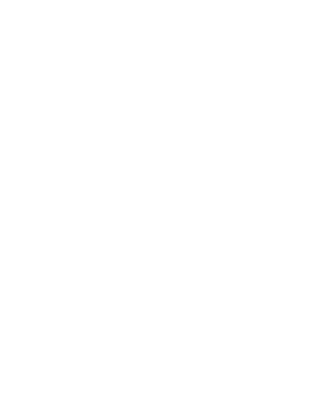

In [ ]:
fig, axis = plt.subplots(figsize=(5, 5))
axis.set_xticks([])
axis.set_yticks([])
patch = plt.imshow(all_grids.iloc[0,0], cmap=plt.cm.binary)

def animate(i):
    patch.set_data(all_grids.iloc[i,0])

anim = animation.FuncAnimation(fig, animate, frames=MAX_GENERATIONS)

In [2]:
anim

NameError: name 'anim' is not defined